In [160]:
import os
import cv2
import numpy as np
import random
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture


In [25]:

# Define the paths for your dataset and output folder
dataset_path = '/Users/prernaalkute/Documents/Project/TinyImageNet100'
output_path = '/Users/prernaalkute/Documents/Project'

def data(dataset_path, output_path, num_classes=15):
    # Create the output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)
    
    # Get all the class folders from the dataset and randomly select the specified number of classes
    class_folders = sorted(os.listdir(dataset_path))
    selected_classes = random.sample(class_folders, num_classes)
    
    print(f"Selected {num_classes} classes: {selected_classes}")
    
    # Create and save class labels to a file
    class_labels_path = os.path.join(output_path, "class_labels.txt")
    with open(class_labels_path, "w") as f:
        for cls in selected_classes:
            f.write(f"{cls}\n")
    
    # Iterate over each selected class to prepare its data
    for cls in selected_classes:
        # Define the path to the class images
        class_images_path = os.path.join(dataset_path, cls, "images")
        
        # Get all the image filenames in the class folder
        images = sorted(os.listdir(class_images_path))
        print(f"Found {len(images)} images in class '{cls}'")
        
        # Split the images into training (first 400) and testing (next 100)
        train_images = images[:400]
        test_images = images[400:500]
        
        # Create directories for training and testing images
        train_dir = os.path.join(output_path, "train", cls)  # Use full class name
        test_dir = os.path.join(output_path, "test", cls)
        os.makedirs(train_dir, exist_ok=True)
        os.makedirs(test_dir, exist_ok=True)
        
        # Copy the training images into the train directory
        for img in train_images:
            img_path = os.path.join(class_images_path, img)
            img_dest_path = os.path.join(train_dir, img)
            os.link(img_path, img_dest_path)  # Create a hard link (alternative: shutil.copy())
        
        # Copy the testing images into the test directory
        for img in test_images:
            img_path = os.path.join(class_images_path, img)
            img_dest_path = os.path.join(test_dir, img)
            os.link(img_path, img_dest_path)  # Create a hard link (alternative: shutil.copy())

    # Print a summary of the dataset preparation
    print(f"Dataset with {num_classes} classes successfully prepared at: {output_path}")
    
    # Count and display the number of images in the train and test directories
    print("\nCounting the images in the train and test directories:")
    for cls in selected_classes:
        train_class_dir = os.path.join(output_path, "train", cls)
        test_class_dir = os.path.join(output_path, "test", cls)
        
        # Count the images in the train directory for the current class
        train_images_count = len(os.listdir(train_class_dir))
        test_images_count = len(os.listdir(test_class_dir))
        
        # Display the count for the current class
        print(f"Class '{cls}':")
        print(f"  Train images: {train_images_count}")
        print(f"  Test images: {test_images_count}")
    
    print("\nCounting completed.")
    
# Run the data function
data(dataset_path, output_path)


Selected 15 classes: ['n02437312', 'n02129165', 'n02699494', 'n02791270', 'n03042490', 'n01945685', 'n01644900', 'n02206856', 'n03100240', 'n01944390', 'n03026506', 'n02948072', 'n02233338', 'n02669723', 'n02666196']
Found 500 images in class 'n02437312'
Found 500 images in class 'n02129165'
Found 500 images in class 'n02699494'
Found 500 images in class 'n02791270'
Found 500 images in class 'n03042490'
Found 500 images in class 'n01945685'
Found 500 images in class 'n01644900'
Found 500 images in class 'n02206856'
Found 500 images in class 'n03100240'
Found 500 images in class 'n01944390'
Found 500 images in class 'n03026506'
Found 500 images in class 'n02948072'
Found 500 images in class 'n02233338'
Found 500 images in class 'n02669723'
Found 500 images in class 'n02666196'
Dataset with 15 classes successfully prepared at: /Users/prernaalkute/Documents/Project

Counting the images in the train and test directories:
Class 'n02437312':
  Train images: 400
  Test images: 100
Class 'n021

# ORB + BOW

SVM Classifier Performance:
              precision    recall  f1-score   support

           0       0.06      0.02      0.03       100
           1       0.40      0.02      0.04       100
           2       0.00      0.00      0.00       100
           3       0.16      0.07      0.10       100
           4       0.07      0.01      0.02       100
           5       0.08      0.01      0.02       100
           6       0.00      0.00      0.00       100
           7       0.09      0.03      0.05       100
           8       0.00      0.00      0.00       100
           9       0.10      0.03      0.05       100
          10       0.14      0.04      0.06       100
          11       0.08      0.02      0.03       100
          12       0.18      0.05      0.08       100
          13       0.07      0.80      0.13       100
          14       0.00      0.00      0.00       100

    accuracy                           0.07      1500
   macro avg       0.10      0.07      0.04      150

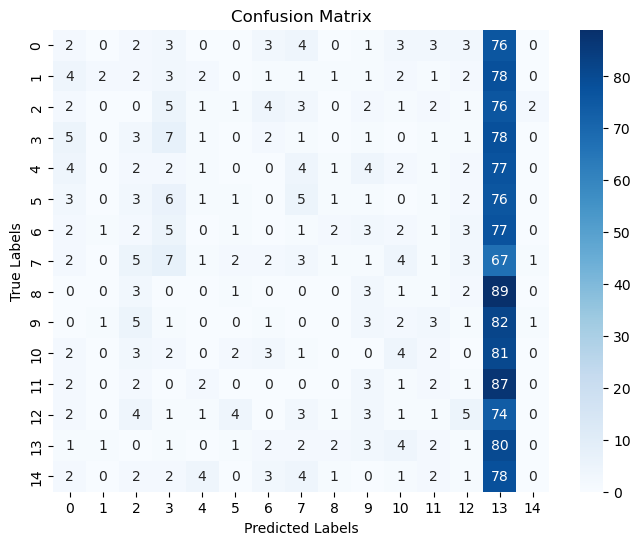

In [177]:
import cv2
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline

def load_images(folder_path, class_labels_file):
    images, labels, image_paths = [], [], []
    
    label_map = {}
    with open(class_labels_file, "r") as f:
        for line in f:
            class_name, label = line.strip().split(",")
            label_map[class_name] = int(label)
    
    for class_name, label in label_map.items():
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                if img_path.lower().endswith(('.jpg', '.png', '.jpeg')):
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        images.append(img)
                        labels.append(label)
                        image_paths.append(img_path)
    
    return images, np.array(labels), image_paths

def extract_features(image_paths, method='ORB'):
    descriptor_list = []
    
    if method == 'ORB':
        detector = cv2.ORB_create()
    else:
        raise ValueError("Invalid method! Choose 'ORB'")
    
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        keypoints, descriptors = detector.detectAndCompute(img, None)
        if descriptors is not None:
            descriptor_list.append(descriptors)
    
    return descriptor_list

def create_bow_dictionary(descriptor_list, num_clusters=100):
    all_descriptors = np.vstack(descriptor_list)
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(all_descriptors)
    return kmeans

def create_feature_vectors(image_paths, kmeans, num_clusters=100):
    feature_vectors = []
    
    detector = cv2.ORB_create()
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        keypoints, descriptors = detector.detectAndCompute(img, None)
        if descriptors is not None:
            labels = kmeans.predict(descriptors)
            hist, _ = np.histogram(labels, bins=np.arange(num_clusters+1))
            feature_vectors.append(hist)
        else:
            feature_vectors.append(np.zeros(num_clusters))
    
    return np.array(feature_vectors)

# Define paths (these should be set according to your folder structure)
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'
class_labels_file = '/Users/prernaalkute/Documents/Project/class_labels.txt'

# Load training and testing images and labels
train_images, train_labels, train_image_paths = load_images(train_path, class_labels_file)
test_images, test_labels, test_image_paths = load_images(test_path, class_labels_file)

# Extract ORB features
descriptor_list = extract_features(train_image_paths, method='ORB')

# Create BoW dictionary using KMeans
kmeans = create_bow_dictionary(descriptor_list)

# Create feature vectors for train and test datasets
X_train = create_feature_vectors(train_image_paths, kmeans)
X_test = create_feature_vectors(test_image_paths, kmeans)

# Scale the feature vectors using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train an SVM classifier
svm = make_pipeline(StandardScaler(), SVC(kernel='linear'))
svm.fit(X_train, train_labels)

# Make predictions on the test set
predictions = svm.predict(X_test)

# Print classification report and accuracy
print("SVM Classifier Performance:")
print(classification_report(test_labels, predictions))
print("Accuracy:", accuracy_score(test_labels, predictions))

#Plot of confusion matrix
cm = confusion_matrix(test_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# SIFT + BOW

SVM Classifier Performance:
              precision    recall  f1-score   support

           0       0.17      0.22      0.19       100
           1       0.16      0.21      0.18       100
           2       0.20      0.26      0.22       100
           3       0.21      0.29      0.24       100
           4       0.20      0.24      0.22       100
           5       0.27      0.17      0.21       100
           6       0.12      0.10      0.11       100
           7       0.22      0.20      0.21       100
           8       0.34      0.36      0.35       100
           9       0.14      0.11      0.12       100
          10       0.22      0.19      0.20       100
          11       0.29      0.25      0.27       100
          12       0.32      0.36      0.34       100
          13       0.24      0.16      0.19       100
          14       0.49      0.36      0.42       100

    accuracy                           0.23      1500
   macro avg       0.24      0.23      0.23      150

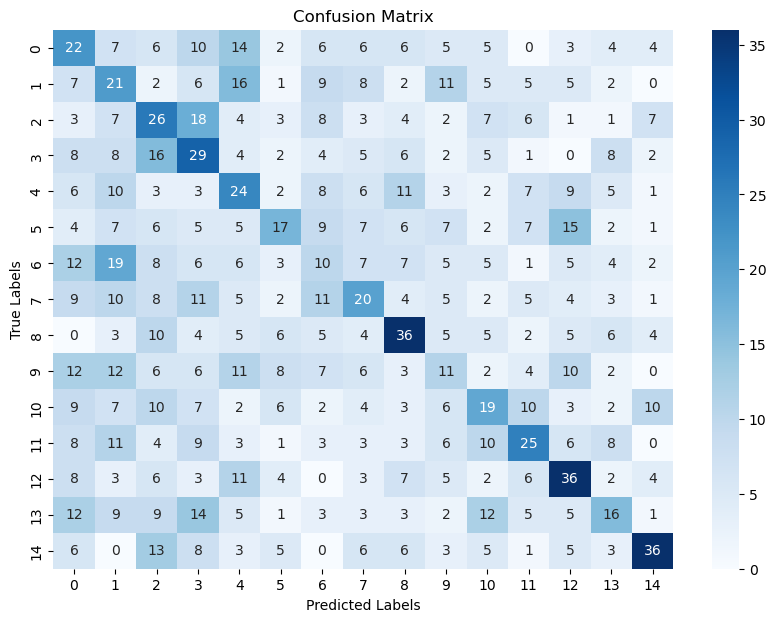

In [157]:
def load_images(folder_path, class_labels_file):
    images, labels, image_paths = [], [], []
    
    label_map = {}
    with open(class_labels_file, "r") as f:
        for line in f:
            class_name, label = line.strip().split(",")
            label_map[class_name] = int(label)
    
    for class_name, label in label_map.items():
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                if img_path.lower().endswith(('.jpg', '.png', '.jpeg')):
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        images.append(img)
                        labels.append(label)
                        image_paths.append(img_path)
    
    return images, np.array(labels), image_paths

def extract_features(image_paths, method='SIFT'):
    descriptor_list = []
    
    if method == 'SIFT':
        detector = cv2.SIFT_create()
    else:
        raise ValueError("Invalid method! Choose 'SIFT'")
    
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        keypoints, descriptors = detector.detectAndCompute(img, None)
        if descriptors is not None:
            descriptor_list.append(descriptors)
    
    return descriptor_list

def create_bow_dictionary(descriptor_list, num_clusters=300):
    all_descriptors = np.vstack(descriptor_list)
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(all_descriptors)
    return kmeans

def create_feature_vectors(image_paths, kmeans, num_clusters=300):
    feature_vectors = []
    
    detector = cv2.SIFT_create()
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            feature_vectors.append(np.zeros(num_clusters))
            continue

        keypoints, descriptors = detector.detectAndCompute(img, None)
        if descriptors is not None:
            labels = kmeans.predict(descriptors)
            hist, _ = np.histogram(labels, bins=np.arange(num_clusters+1))
            feature_vectors.append(hist)
        else:
            feature_vectors.append(np.zeros(num_clusters))
    
    return np.array(feature_vectors)

# Define paths
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'
class_labels_file = '/Users/prernaalkute/Documents/Project/class_labels.txt'

# Load training and testing images and labels
train_images, train_labels, train_image_paths = load_images(train_path, class_labels_file)
test_images, test_labels, test_image_paths = load_images(test_path, class_labels_file)

# Extract SIFT features
descriptor_list = extract_features(train_image_paths)

# Create BoW dictionary using KMeans
kmeans = create_bow_dictionary(descriptor_list, num_clusters=300)

# Create feature vectors for train and test datasets
X_train = create_feature_vectors(train_image_paths, kmeans, num_clusters=300)
X_test = create_feature_vectors(test_image_paths, kmeans, num_clusters=300)

# Scale the feature vectors using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=50)  
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# Create and train an SVM classifier with RBF kernel
svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10, gamma='scale'))
svm.fit(X_train, train_labels)

# Make predictions on the test set
predictions = svm.predict(X_test)

# Print classification report and accuracy
print("SVM Classifier Performance:")
print(classification_report(test_labels, predictions))
print("Accuracy:", accuracy_score(test_labels, predictions))

# Compute and plot confusion matrix
conf_matrix = confusion_matrix(test_labels, predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


# ORB + Fisher

SVM Classifier Performance:
              precision    recall  f1-score   support

           0       0.12      0.03      0.05       100
           1       0.04      0.02      0.03       100
           2       0.12      0.04      0.06       100
           3       0.09      0.02      0.03       100
           4       0.08      0.02      0.03       100
           5       0.09      0.03      0.05       100
           6       0.14      0.03      0.05       100
           7       0.12      0.04      0.06       100
           8       0.07      0.01      0.02       100
           9       0.05      0.01      0.02       100
          10       0.12      0.02      0.03       100
          11       0.00      0.00      0.00       100
          12       0.12      0.02      0.03       100
          13       0.07      0.79      0.12       100
          14       0.11      0.01      0.02       100

    accuracy                           0.07      1500
   macro avg       0.09      0.07      0.04      150

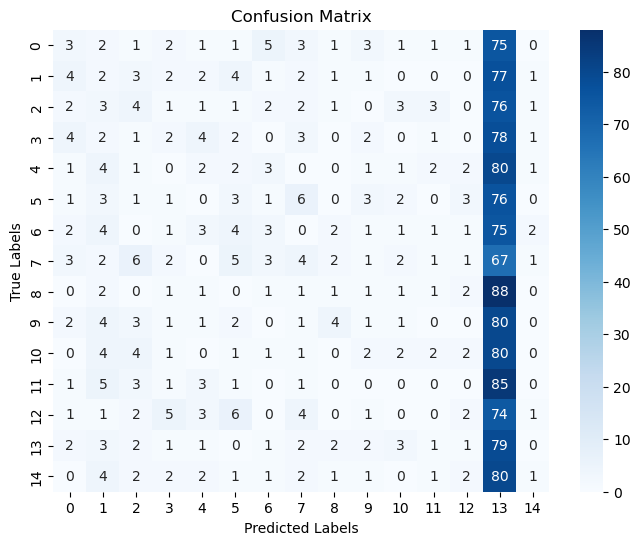

In [181]:
import cv2
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

def load_images(folder_path, class_labels_file):
    images, labels, image_paths = [], [], []
    
    label_map = {}
    with open(class_labels_file, "r") as f:
        for line in f:
            class_name, label = line.strip().split(",")
            label_map[class_name] = int(label)
    
    for class_name, label in label_map.items():
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                if img_path.lower().endswith(('.jpg', '.png', '.jpeg')):
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        images.append(img)
                        labels.append(label)
                        image_paths.append(img_path)
    
    return images, np.array(labels), image_paths

def extract_features(image_paths):
    descriptor_list = []
    detector = cv2.ORB_create(nfeatures=500)  # ORB instead of SIFT
    
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        keypoints, descriptors = detector.detectAndCompute(img, None)
        if descriptors is not None:
            descriptors = descriptors.astype(np.float32)  # Convert binary descriptors to float
            descriptor_list.append(descriptors)
    
    return descriptor_list

def train_gmm(descriptor_list, num_clusters=64):  # Reduced clusters for ORB's smaller descriptors
    all_descriptors = np.vstack(descriptor_list)
    
    # Normalize descriptors
    all_descriptors = all_descriptors.astype(np.float32) / 255.0
    
    gmm = GaussianMixture(
        n_components=num_clusters, 
        covariance_type='diag',  # Use diagonal covariance
        max_iter=500, 
        random_state=42, 
        init_params='kmeans'
    )
    
    gmm.fit(all_descriptors)
    return gmm

def fisher_vector(descriptors, gmm):
    if descriptors is None or len(descriptors) == 0:
        return np.zeros(2 * gmm.n_components * gmm.means_.shape[1])

    # Get GMM parameters
    means = gmm.means_
    variances = gmm.covariances_
    weights = gmm.weights_
    
    # Predict posterior probabilities
    probabilities = gmm.predict_proba(descriptors)
    
    fisher_vector_mean = np.zeros_like(means)
    fisher_vector_cov = np.zeros_like(means)

    for i in range(gmm.n_components):
        diff = descriptors - means[i]
        fisher_vector_mean[i] = np.sum(probabilities[:, i][:, np.newaxis] * diff, axis=0) / (np.sqrt(weights[i]))
        fisher_vector_cov[i] = np.sum(probabilities[:, i][:, np.newaxis] * (diff ** 2 - variances[i]), axis=0) / (np.sqrt(2 * weights[i]))

    fisher_vector = np.hstack([fisher_vector_mean.flatten(), fisher_vector_cov.flatten()])
    return fisher_vector

def create_fisher_vectors(image_paths, gmm):
    feature_vectors = []
    detector = cv2.ORB_create(nfeatures=500)  # ORB instead of SIFT
    
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        keypoints, descriptors = detector.detectAndCompute(img, None)
        if descriptors is not None:
            descriptors = descriptors.astype(np.float32)  # Convert binary descriptors to float
        fisher_vec = fisher_vector(descriptors, gmm)
        feature_vectors.append(fisher_vec)
    
    return np.array(feature_vectors)

# Define paths
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'
class_labels_file = '/Users/prernaalkute/Documents/Project/class_labels.txt'

# Load images and labels
train_images, train_labels, train_image_paths = load_images(train_path, class_labels_file)
test_images, test_labels, test_image_paths = load_images(test_path, class_labels_file)

# Extract ORB features
descriptor_list = extract_features(train_image_paths)

# Train GMM on ORB descriptors
gmm = train_gmm(descriptor_list)

# Create Fisher Vectors for train and test datasets
X_train = create_fisher_vectors(train_image_paths, gmm)
X_test = create_fisher_vectors(test_image_paths, gmm)

# Scale the feature vectors
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM classifier
svm = SVC(kernel='linear')
svm.fit(X_train, train_labels)

# Make predictions
predictions = svm.predict(X_test)

# Print results
print("SVM Classifier Performance:")
print(classification_report(test_labels, predictions))
print("Accuracy:", accuracy_score(test_labels, predictions))

# Plot confusion matrix
cm = confusion_matrix(test_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


# Fisher vector + SIFT

SVM Classifier Performance:
              precision    recall  f1-score   support

           0       0.20      0.28      0.23       100
           1       0.19      0.21      0.20       100
           2       0.20      0.25      0.22       100
           3       0.20      0.24      0.22       100
           4       0.14      0.17      0.15       100
           5       0.20      0.16      0.18       100
           6       0.18      0.13      0.15       100
           7       0.15      0.14      0.14       100
           8       0.39      0.45      0.42       100
           9       0.19      0.19      0.19       100
          10       0.24      0.20      0.22       100
          11       0.24      0.19      0.21       100
          12       0.30      0.20      0.24       100
          13       0.28      0.30      0.29       100
          14       0.42      0.32      0.36       100

    accuracy                           0.23      1500
   macro avg       0.23      0.23      0.23      150

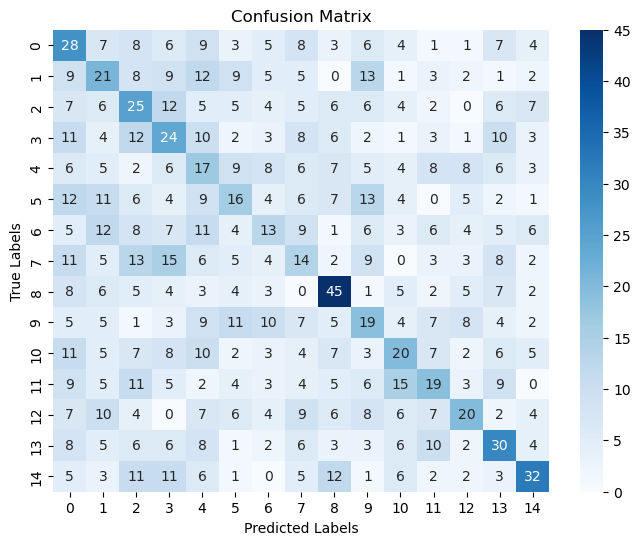

In [38]:
import cv2
import numpy as np
import os
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

def load_images(folder_path, class_labels_file):
    images, labels, image_paths = [], [], []
    
    label_map = {}
    with open(class_labels_file, "r") as f:
        for line in f:
            class_name, label = line.strip().split(",")
            label_map[class_name] = int(label)
    
    for class_name, label in label_map.items():
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            for img_name in os.listdir(class_folder):
                img_path = os.path.join(class_folder, img_name)
                if img_path.lower().endswith(('.jpg', '.png', '.jpeg')):
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        images.append(img)
                        labels.append(label)
                        image_paths.append(img_path)
    
    return images, np.array(labels), image_paths

def extract_features(image_paths):
    descriptor_list = []
    detector = cv2.SIFT_create()
    
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        keypoints, descriptors = detector.detectAndCompute(img, None)
        if descriptors is not None:
            descriptor_list.append(descriptors)
    
    return descriptor_list

def train_gmm(descriptor_list, num_clusters=100):
    all_descriptors = np.vstack(descriptor_list)
    
    # Normalize descriptors
    all_descriptors = all_descriptors.astype(np.float32) / 255.0
    
    gmm = GaussianMixture(
        n_components=num_clusters, 
        covariance_type='diag',  # Use diagonal covariance
        max_iter=500, 
        random_state=42, 
        init_params='kmeans'
    )
    
    gmm.fit(all_descriptors)
    return gmm

def fisher_vector(descriptors, gmm):
    if descriptors is None or len(descriptors) == 0:
        return np.zeros(2 * gmm.n_components * gmm.means_.shape[1])

    # Get GMM parameters
    means = gmm.means_
    variances = gmm.covariances_
    weights = gmm.weights_
    
    # Predict posterior probabilities
    probabilities = gmm.predict_proba(descriptors)
    
    fisher_vector_mean = np.zeros_like(means)
    fisher_vector_cov = np.zeros_like(means)  # Shape matches means (not covariances)

    for i in range(gmm.n_components):
        diff = descriptors - means[i]
        fisher_vector_mean[i] = np.sum(probabilities[:, i][:, np.newaxis] * diff, axis=0) / (np.sqrt(weights[i]))
        fisher_vector_cov[i] = np.sum(probabilities[:, i][:, np.newaxis] * (diff ** 2 - variances[i]), axis=0) / (np.sqrt(2 * weights[i]))

    fisher_vector = np.hstack([fisher_vector_mean.flatten(), fisher_vector_cov.flatten()])
    return fisher_vector

def create_fisher_vectors(image_paths, gmm):
    feature_vectors = []
    detector = cv2.SIFT_create()
    
    for img_path in image_paths:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        keypoints, descriptors = detector.detectAndCompute(img, None)
        fisher_vec = fisher_vector(descriptors, gmm)
        feature_vectors.append(fisher_vec)
    
    return np.array(feature_vectors)

# Define paths (set accordingly)
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'
class_labels_file = '/Users/prernaalkute/Documents/Project/class_labels.txt'

# Load images and labels
train_images, train_labels, train_image_paths = load_images(train_path, class_labels_file)
test_images, test_labels, test_image_paths = load_images(test_path, class_labels_file)

# Extract SIFT features
descriptor_list = extract_features(train_image_paths)

# Train GMM on SIFT descriptors
gmm = train_gmm(descriptor_list)

# Create Fisher Vectors for train and test datasets
X_train = create_fisher_vectors(train_image_paths, gmm)
X_test = create_fisher_vectors(test_image_paths, gmm)

# Scale the feature vectors
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM classifier
svm = SVC(kernel='linear')
svm.fit(X_train, train_labels)

# Make predictions
predictions = svm.predict(X_test)

# Print results
print("SVM Classifier Performance:")
print(classification_report(test_labels, predictions))
print("Accuracy:", accuracy_score(test_labels, predictions))

# Plot confusion matrix
cm = confusion_matrix(test_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Phase 3: Conduct image classification using the neural network approach

In [185]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torchvision.transforms as transforms
# import torchvision.datasets as datasets
# from torch.utils.data import DataLoader
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix, classification_report

# # Define device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Define paths
# train_path = '/Users/prernaalkute/Documents/Project/train'
# test_path = '/Users/prernaalkute/Documents/Project/test'

# # Define transformations (Data Augmentation + Normalization)
# transform = transforms.Compose([
#     transforms.Resize((128, 128)),  # Resize images to 128x128
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(20),
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Color augmentation
#     transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),  # Randomly crop and resize
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalization
# ])

# # Load datasets
# train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
# test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# # Define class names
# class_names = train_dataset.classes
# num_classes = len(class_names)

# # Define DataLoaders
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# # Dynamically determine input size
# sample_image, _ = next(iter(train_loader))
# _, C, H, W = sample_image.shape  # Get image channels, height, width
# input_size = H * W * C  # Flattened image size

# # Define Neural Network Model
# class NNModel(nn.Module):
#     def __init__(self, input_size, hidden_units, output_size):
#         super(NNModel, self).__init__()
#         self.layer_stack = nn.Sequential(
#             nn.Flatten(),  # Flatten input image
#             nn.Linear(input_size, hidden_units),  # First hidden layer
#             nn.ReLU(),
#             nn.BatchNorm1d(hidden_units),  # Batch Normalization
#             nn.Dropout(0.5),  # Dropout for regularization
#             nn.Linear(hidden_units, hidden_units // 2),  # Second hidden layer
#             nn.ReLU(),
#             nn.BatchNorm1d(hidden_units // 2),
#             nn.Dropout(0.5),
#             nn.Linear(hidden_units // 2, output_size)  # Output layer
#         )

#     def forward(self, x):
#         return self.layer_stack(x)

# # Initialize model, loss function, and optimizer
# model = NNModel(input_size=input_size, hidden_units=512, output_size=num_classes).to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


# # Lists to track loss and accuracy
# train_losses = []
# train_accuracies = []

# # Train the model
# num_epochs = 40
# for epoch in range(num_epochs):
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0
    
#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)
#         images = images.view(images.size(0), -1)  # Flatten images

#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()
#         _, predicted = torch.max(outputs, 1)
#         correct += (predicted == labels).sum().item()
#         total += labels.size(0)

#     train_accuracy = correct / total
#     train_losses.append(running_loss / len(train_loader))
#     train_accuracies.append(train_accuracy)

#     print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}, Accuracy: {train_accuracies[-1]:.4f}")

# # Plot training loss and accuracy
# epochs = range(1, num_epochs + 1)

# # Loss plot
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.plot(epochs, train_losses, label='Training Loss', color='red')
# plt.title("Training Loss Over Epochs")
# plt.xlabel("Epochs")
# plt.ylabel("Loss")
# plt.legend()

# # Accuracy plot
# plt.subplot(1, 2, 2)
# plt.plot(epochs, train_accuracies, label='Training Accuracy', color='blue')
# plt.title("Training Accuracy Over Epochs")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.legend()

# plt.tight_layout()
# plt.show()

# # Evaluate the model
# model.eval()
# all_preds = []
# all_labels = []

# with torch.no_grad():
#     correct = 0
#     total = 0
#     for images, labels in test_loader:
#         images, labels = images.to(device), labels.to(device)
#         images = images.view(images.size(0), -1)  # Flatten images
#         outputs = model(images)
#         _, predicted = torch.max(outputs, 1)
        
#         all_preds.extend(predicted.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())
#         correct += (predicted == labels).sum().item()
#         total += labels.size(0)

# test_accuracy = correct / total
# print(f"Test Accuracy: {test_accuracy:.4f}")

# # Print classification report
# print("Neural Network Classifier Performance:")
# print(classification_report(all_labels, all_preds, target_names=class_names))

# # Confusion Matrix
# cm = confusion_matrix(all_labels, all_preds)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted Labels")
# plt.ylabel("True Labels")
# plt.show()


In [146]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define paths
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'

# Define improved transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(128, scale=(0.9, 1.0)),  # Less aggressive cropping
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalization
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Define class names
class_names = train_dataset.classes
num_classes = len(class_names)

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Dynamically determine input size
sample_image, _ = next(iter(train_loader))
_, C, H, W = sample_image.shape  # Get image channels, height, width
input_size = H * W * C  # Flattened image size

# Define Neural Network Model with Improvements
class ImprovedNNModel(nn.Module):
    def __init__(self, input_size, hidden_units, output_size):
        super(ImprovedNNModel, self).__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_units),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_units),
            nn.Dropout(0.3),  # Reduced dropout
            nn.Linear(hidden_units, hidden_units // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_units // 2),
            nn.Dropout(0.3),
            nn.Linear(hidden_units // 2, output_size)
        )

    def forward(self, x):
        return self.layer_stack(x)

# Initialize model, loss function, and optimizer
model = ImprovedNNModel(input_size=input_size, hidden_units=512, output_size=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)  # Lower learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Lists to track loss and accuracy
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Early stopping
early_stopping_patience = 7
best_val_loss = float('inf')
epochs_no_improve = 0

# Train the model
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    # Validation Phase
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            images = images.view(images.size(0), -1)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total
    val_losses.append(val_loss / len(test_loader))
    val_accuracies.append(val_accuracy)

    scheduler.step(val_losses[-1])

    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

    # Early stopping
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered!")
            break


Epoch [1/50] -> Train Loss: 2.5617, Train Acc: 0.1827, Val Loss: 2.3529, Val Acc: 0.2487
Epoch [2/50] -> Train Loss: 2.3728, Train Acc: 0.2412, Val Loss: 2.2544, Val Acc: 0.2820
Epoch [3/50] -> Train Loss: 2.2990, Train Acc: 0.2662, Val Loss: 2.2395, Val Acc: 0.2853
Epoch [4/50] -> Train Loss: 2.2557, Train Acc: 0.2705, Val Loss: 2.2075, Val Acc: 0.2907
Epoch [5/50] -> Train Loss: 2.1931, Train Acc: 0.2952, Val Loss: 2.1916, Val Acc: 0.3053
Epoch [6/50] -> Train Loss: 2.1631, Train Acc: 0.3048, Val Loss: 2.1524, Val Acc: 0.3053
Epoch [7/50] -> Train Loss: 2.1285, Train Acc: 0.3253, Val Loss: 2.1461, Val Acc: 0.3207
Epoch [8/50] -> Train Loss: 2.1192, Train Acc: 0.3148, Val Loss: 2.1293, Val Acc: 0.3147
Epoch [9/50] -> Train Loss: 2.0941, Train Acc: 0.3232, Val Loss: 2.1307, Val Acc: 0.3173
Epoch [10/50] -> Train Loss: 2.0861, Train Acc: 0.3287, Val Loss: 2.1292, Val Acc: 0.3227
Epoch [11/50] -> Train Loss: 2.0716, Train Acc: 0.3285, Val Loss: 2.1267, Val Acc: 0.3113
Epoch [12/50] -> Tr


Neural Network Classifier Performance:
              precision    recall  f1-score   support

   n01644900       0.22      0.22      0.22       100
   n01944390       0.25      0.17      0.20       100
   n01945685       0.23      0.10      0.14       100
   n02129165       0.31      0.45      0.36       100
   n02206856       0.61      0.52      0.56       100
   n02233338       0.30      0.34      0.32       100
   n02437312       0.40      0.54      0.46       100
   n02666196       0.28      0.16      0.20       100
   n02669723       0.47      0.46      0.47       100
   n02699494       0.36      0.32      0.34       100
   n02791270       0.28      0.32      0.30       100
   n02948072       0.41      0.44      0.42       100
   n03026506       0.46      0.58      0.51       100
   n03042490       0.38      0.38      0.38       100
   n03100240       0.55      0.62      0.58       100

    accuracy                           0.37      1500
   macro avg       0.37      0.37      0

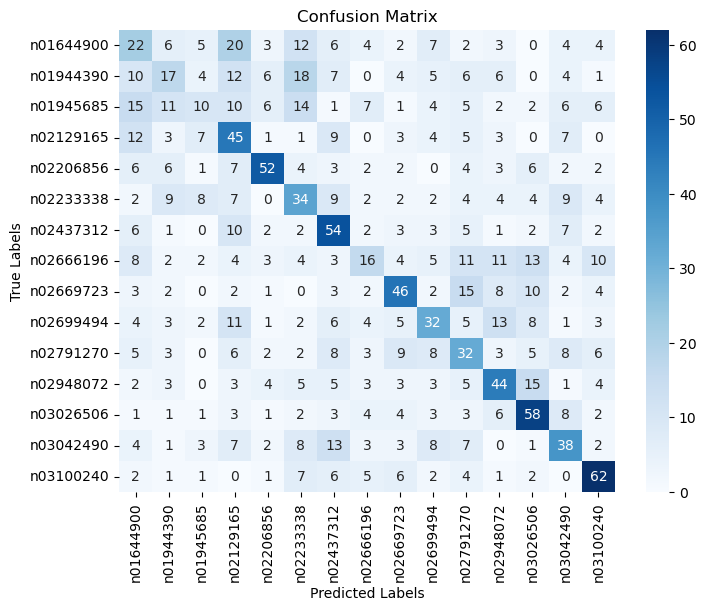

In [126]:
# Evaluate the model and print classification report
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print classification report
print("\nNeural Network Classifier Performance:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


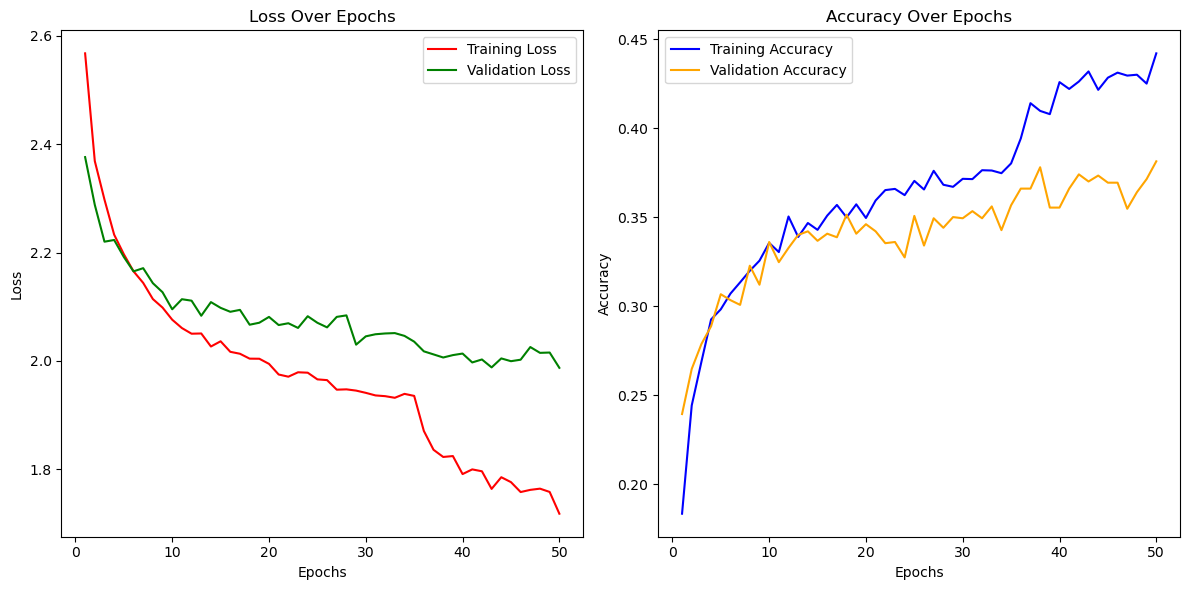

In [128]:
# Plot training and validation loss & accuracy
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', color='red')
plt.plot(epochs, val_losses, label='Validation Loss', color='green')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training Accuracy', color='blue')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='orange')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


# Phase 4: Conduct image classification using the convolutional neural network approach

Epoch [1/50], Loss: 2.6157, Accuracy: 0.1322
Epoch [2/50], Loss: 2.4260, Accuracy: 0.2147
Epoch [3/50], Loss: 2.3088, Accuracy: 0.2475
Epoch [4/50], Loss: 2.2388, Accuracy: 0.2775
Epoch [5/50], Loss: 2.1629, Accuracy: 0.3015
Epoch [6/50], Loss: 2.1285, Accuracy: 0.3153
Epoch [7/50], Loss: 2.0793, Accuracy: 0.3285
Epoch [8/50], Loss: 2.0463, Accuracy: 0.3422
Epoch [9/50], Loss: 2.0247, Accuracy: 0.3405
Epoch [10/50], Loss: 2.0017, Accuracy: 0.3595
Epoch [11/50], Loss: 1.9496, Accuracy: 0.3738
Epoch [12/50], Loss: 1.9079, Accuracy: 0.3812
Epoch [13/50], Loss: 1.8829, Accuracy: 0.3903
Epoch [14/50], Loss: 1.8651, Accuracy: 0.4035
Epoch [15/50], Loss: 1.8443, Accuracy: 0.4037
Epoch [16/50], Loss: 1.8172, Accuracy: 0.4182
Epoch [17/50], Loss: 1.8001, Accuracy: 0.4232
Epoch [18/50], Loss: 1.7829, Accuracy: 0.4225
Epoch [19/50], Loss: 1.7622, Accuracy: 0.4298
Epoch [20/50], Loss: 1.7396, Accuracy: 0.4375
Epoch [21/50], Loss: 1.7169, Accuracy: 0.4382
Epoch [22/50], Loss: 1.6960, Accuracy: 0.45

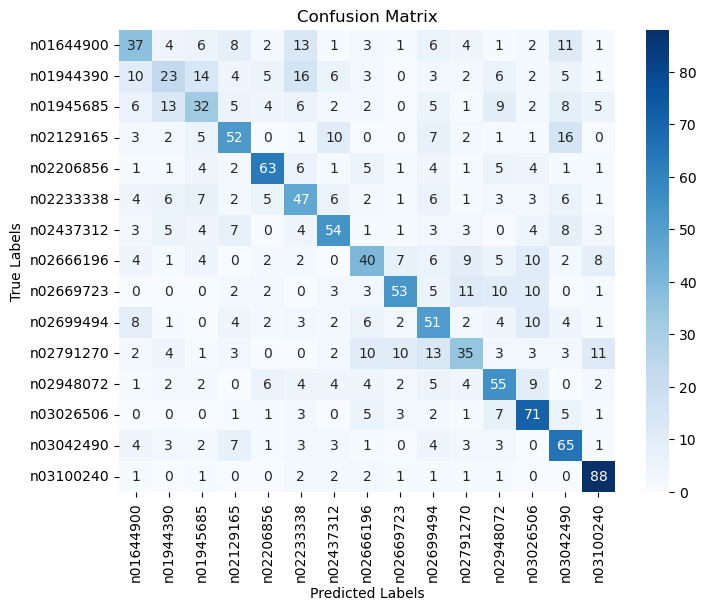

In [87]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import copy

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define paths
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'

# Define Data Augmentation and Normalization
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),  # Flip images horizontally
    transforms.RandomRotation(20),  # Rotate images
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Define class names
class_names = train_dataset.classes
num_classes = len(class_names)

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # Conv Layer 1
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduce size by half
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Conv Layer 2
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # Conv Layer 3
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),  # Conv Layer 4
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),  # Fully connected layer
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),  # Dropout for regularization
            
            nn.Linear(512, num_classes)  # Output layer
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Initialize model, loss function, optimizer, and scheduler
model = CNNModel(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Early Stopping
patience = 10
best_loss = float('inf')
epochs_without_improvement = 0
best_model_wts = copy.deepcopy(model.state_dict())

# Lists to track loss and accuracy
train_losses, train_accuracies = [], []
valid_losses, valid_accuracies = [], []

# Training loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    # Validation Step
    model.eval()
    valid_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    valid_accuracy = correct / total
    valid_losses.append(valid_loss / len(test_loader))
    valid_accuracies.append(valid_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Valid Loss: {valid_losses[-1]:.4f}, Valid Acc: {valid_accuracies[-1]:.4f}")

    # Check for Early Stopping
    if valid_losses[-1] < best_loss:
        best_loss = valid_losses[-1]
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping triggered!")
        break

    scheduler.step(valid_loss)

# Load the best model weights
model.load_state_dict(best_model_wts)

# Plot training curves
plt.figure(figsize=(12, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color='red')
plt.plot(range(1, len(valid_losses) + 1), valid_losses, label='Validation Loss', color='blue')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training Accuracy', color='red')
plt.plot(range(1, len(valid_accuracies) + 1), valid_accuracies, label='Validation Accuracy', color='blue')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Evaluate Model Performance
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    correct, total = 0, 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.show()


In [132]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define paths
train_path = '/Users/prernaalkute/Documents/Project/train'
test_path = '/Users/prernaalkute/Documents/Project/test'

# Define enhanced transformations with data augmentation
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Resize images to 128x128
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),  # More aggressive cropping
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Color augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalization
])

# Load datasets
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Define class names
class_names = train_dataset.classes
num_classes = len(class_names)

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define CNN Model with multiple layers and dropout
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv_block = nn.Sequential(
            # First Convolution Block
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  # Convolution layer
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Max Pooling

            # Second Convolution Block
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Third Convolution Block
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Fourth Convolution Block
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),  # Adjust input size after conv layers and pooling
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout layer for regularization
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x

# Initialize the model, loss function, and optimizer
model = CNNModel(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)  # Suitable learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3)


# Lists to track loss and accuracy
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Early stopping
early_stopping_patience = 7
best_val_loss = float('inf')
epochs_no_improve = 0

# Train the model
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_accuracy = correct / total
    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(train_accuracy)

    # Validation Phase
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total
    val_losses.append(val_loss / len(test_loader))
    val_accuracies.append(val_accuracy)

    scheduler.step(val_losses[-1])

    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

    # Early stopping
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stopping_patience:
            print("Early stopping triggered!")
            break

# Print final training and test accuracy
print(f"\nFinal Training Accuracy: {train_accuracies[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_accuracies[-1] * 100:.2f}%")

# Evaluate the model on the test dataset
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total

# Print final test accuracy
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")




Epoch [1/50] -> Train Loss: 2.7814, Train Acc: 0.1702, Val Loss: 2.5162, Val Acc: 0.2200
Epoch [2/50] -> Train Loss: 2.3787, Train Acc: 0.2385, Val Loss: 2.2612, Val Acc: 0.2893
Epoch [3/50] -> Train Loss: 2.2505, Train Acc: 0.2755, Val Loss: 2.1139, Val Acc: 0.3247
Epoch [4/50] -> Train Loss: 2.1470, Train Acc: 0.3070, Val Loss: 2.0100, Val Acc: 0.3593
Epoch [5/50] -> Train Loss: 2.0721, Train Acc: 0.3370, Val Loss: 1.9409, Val Acc: 0.3680
Epoch [6/50] -> Train Loss: 1.9603, Train Acc: 0.3642, Val Loss: 1.9138, Val Acc: 0.3867
Epoch [7/50] -> Train Loss: 1.9353, Train Acc: 0.3872, Val Loss: 1.7985, Val Acc: 0.4300
Epoch [8/50] -> Train Loss: 1.8677, Train Acc: 0.4002, Val Loss: 1.8333, Val Acc: 0.4240
Epoch [9/50] -> Train Loss: 1.7553, Train Acc: 0.4297, Val Loss: 1.7132, Val Acc: 0.4573
Epoch [10/50] -> Train Loss: 1.7004, Train Acc: 0.4558, Val Loss: 1.6548, Val Acc: 0.4687
Epoch [11/50] -> Train Loss: 1.6506, Train Acc: 0.4690, Val Loss: 1.6602, Val Acc: 0.4713
Epoch [12/50] -> Tr


CNN Classifier Performance:
              precision    recall  f1-score   support

   n01644900       0.34      0.21      0.26       100
   n01944390       0.30      0.19      0.23       100
   n01945685       0.26      0.14      0.18       100
   n02129165       0.34      0.43      0.38       100
   n02206856       0.50      0.54      0.52       100
   n02233338       0.37      0.29      0.32       100
   n02437312       0.34      0.50      0.41       100
   n02666196       0.21      0.11      0.14       100
   n02669723       0.52      0.33      0.40       100
   n02699494       0.33      0.39      0.35       100
   n02791270       0.26      0.37      0.30       100
   n02948072       0.41      0.49      0.45       100
   n03026506       0.44      0.48      0.46       100
   n03042490       0.31      0.41      0.35       100
   n03100240       0.52      0.65      0.58       100

    accuracy                           0.37      1500
   macro avg       0.36      0.37      0.36      15

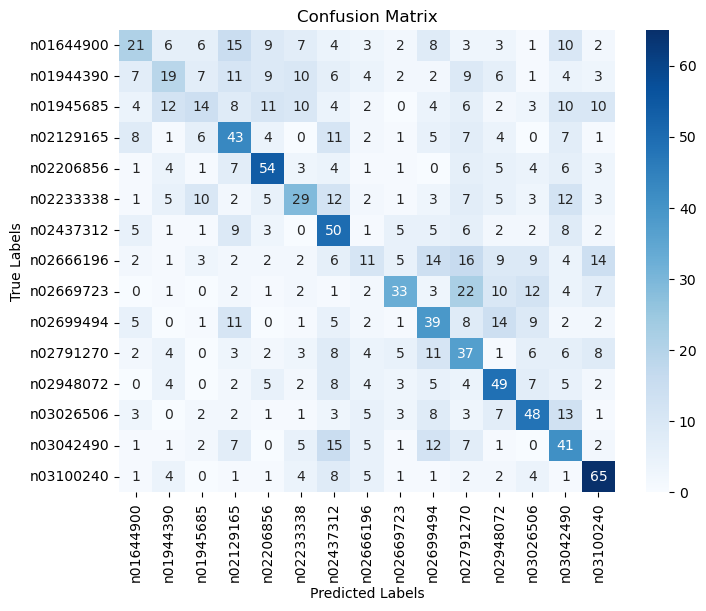

In [162]:
# Evaluate the model and print classification report
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print classification report
print("\nCNN Classifier Performance:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


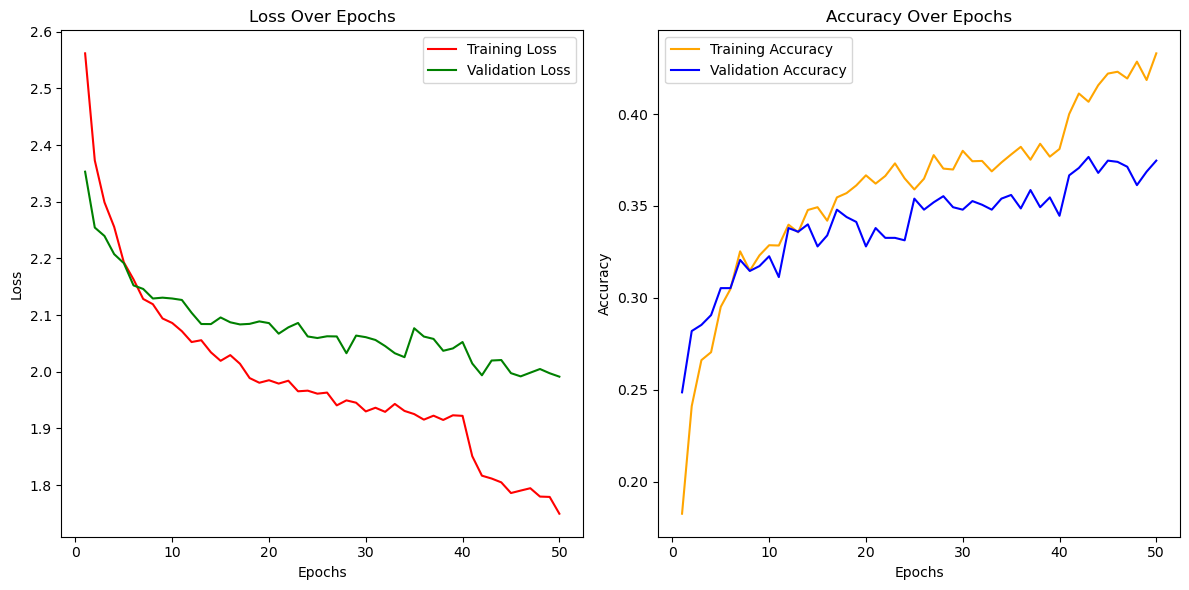

In [164]:
# Plot training and validation loss & accuracy
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Training Loss', color='red')
plt.plot(epochs, val_losses, label='Validation Loss', color='green')
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Training Accuracy', color='orange')
plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='blue')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()